C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Đã kết nối MySQL và đọc thành công 30,336 bản ghi từ bảng 'aqi_data'


14:39:50 - cmdstanpy - INFO - Chain [1] start processing
14:39:56 - cmdstanpy - INFO - Chain [1] done processing


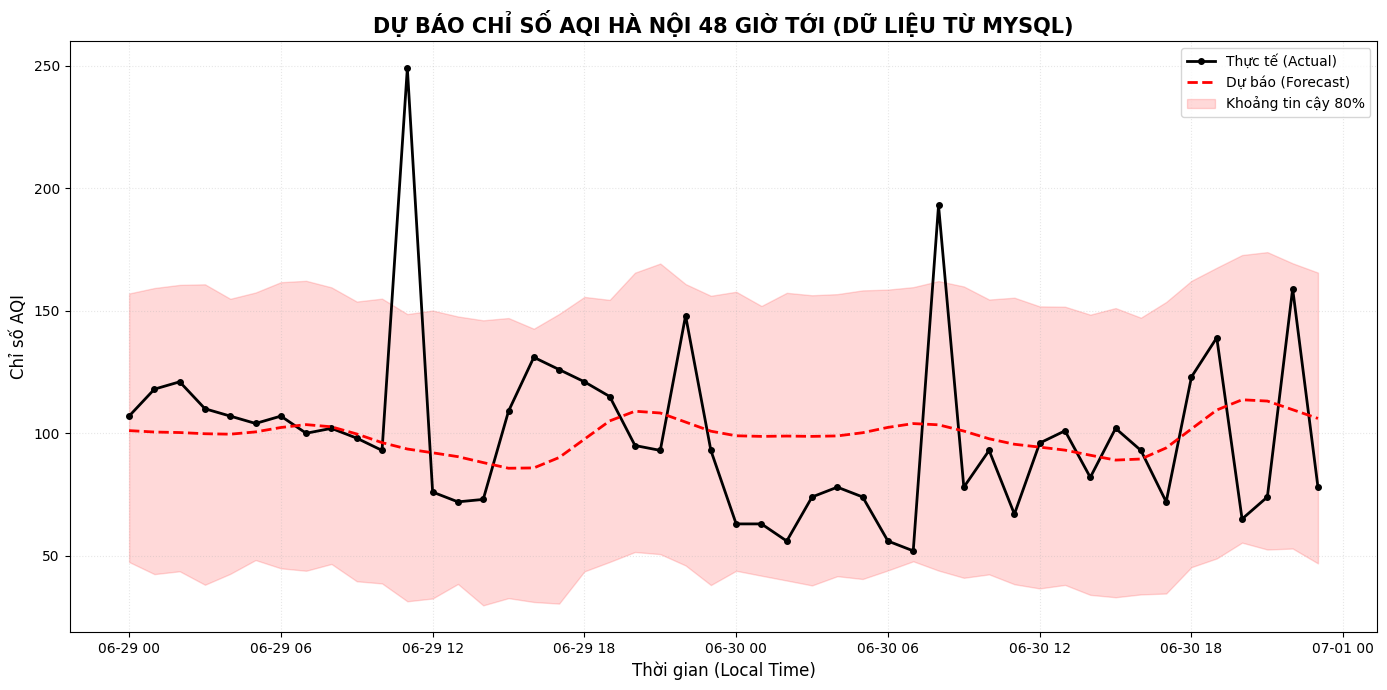

Hệ thống: Hoàn thành chạy dự báo vận hành dựa trên nguồn dữ liệu SQL.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sqlalchemy import create_engine
import warnings
import os
from dotenv import load_dotenv
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)

current_dir = Path(os.getcwd()).resolve()
if 'library_framework' in current_dir.parts:
    dotenv_path = current_dir.parent / '.env'
else:
    dotenv_path = current_dir / '.env'
load_dotenv(dotenv_path=dotenv_path)

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

try:
    query = "SELECT * FROM aqi_data"
    df = pd.read_sql(query, con=engine)
    print(f"✅ Đã kết nối MySQL và đọc thành công {len(df):,} bản ghi từ bảng 'aqi_data'")
except Exception as e:
    print(f"❌ Lỗi kết nối hoặc không tìm thấy bảng sạch: {e}")

df.columns = df.columns.str.strip().str.lower()
df['ds'] = pd.to_datetime(df['local_time'])
df['y'] = pd.to_numeric(df['aqi'], errors='coerce')
df = df.dropna(subset=['ds', 'y'])

test_size = 48
train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(train)

future = model.make_future_dataframe(periods=test_size, freq='h')
forecast = model.predict(future)

plt.figure(figsize=(14, 7))
plt.plot(test['ds'], test['y'], label='Thực tế (Actual)', color='black', marker='o', markersize=4, linewidth=2)
plt.plot(forecast['ds'].tail(test_size), forecast['yhat'].tail(test_size), label='Dự báo (Forecast)', color='red', linestyle='--', linewidth=2)
plt.fill_between(forecast['ds'].tail(test_size), forecast['yhat_lower'].tail(test_size), forecast['yhat_upper'].tail(test_size), color='red', alpha=0.15, label='Khoảng tin cậy 80%')

plt.title('DỰ BÁO CHỈ SỐ AQI HÀ NỘI 48 GIỜ TỚI (DỮ LIỆU TỪ MYSQL)', fontsize=15, fontweight='bold')
plt.xlabel('Thời gian (Local Time)', fontsize=12)
plt.ylabel('Chỉ số AQI', fontsize=12)
plt.legend()
plt.grid(alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

print(f"Hệ thống: Hoàn thành chạy dự báo vận hành dựa trên nguồn dữ liệu SQL.")